# Rabbits and foxes, with `solve_ivp`

**CHME 5137, Lecture 8, Tuesday October 6, 2026.** Started in class, finished for
homework.

*Revised for 2026 by Claude Code (Claude Opus 5.5) from the Lecture 3 notebook, and
checked by Prof. West. The problem is from Chapter 1 of H. Scott Fogler's
"Essentials of Chemical Reaction Engineering". The tasks are new.*

---

There are initially 400 rabbits and 200 foxes on a farm. (Or two cell types in a
96-well plate, if you prefer.) The populations obey

$$\frac{dR}{dt} = k_1 R - k_2 R F \qquad\qquad \frac{dF}{dt} = k_3 R F - k_4 F$$

* Growth of rabbits, $k_1 = 0.015$ day$^{-1}$
* Death of rabbits being eaten by foxes, $k_2 = 0.00004$ day$^{-1}$ foxes$^{-1}$
* Growth of foxes after eating rabbits, $k_3 = 0.0004$ day$^{-1}$ rabbits$^{-1}$
* Death of foxes, $k_4 = 0.04$ day$^{-1}$

In Lecture 3 you solved this with Euler's method. You found that the fox peaks,
which should all be the same height, crept upwards. At a step of 0.1 days (12,000
steps for 1200 days) they went 2816, 2854, 2893. At 0.005 days (240,000 steps) they
went 2804.5, 2806.4, 2808.2. Today: how well does a library do, and at what cost?

### How to work

- **Commit as you go.** After each numbered task works, Restart & Run All, then
  stage, commit with a message that says what you did, and push. At least one commit
  per task. Your commit history is part of what gets looked at.
- **Answer the questions in words**, in the markdown cells marked *Answer*.
  Double-click a cell to edit it.
- **Use the in-class notebook**, `solve-ivp-intro.ipynb`, for the syntax.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

k1 = 0.015  # 1/day
k2 = 0.00004  # 1/day/fox
k3 = 0.0004  # 1/day/rabbit
k4 = 0.04  # 1/day

y0 = [400.0, 200.0]  # [rabbits, foxes] at t = 0

## 1. Solve it, and plot it

Write a function `dydt(t, y)` that returns $[dR/dt,\ dF/dt]$. Then call
`solve_ivp` with its **default** settings for 600 days.

Print `sol.success`, `sol.nfev` and `len(sol.t)`. Then plot both populations
against time, with axis labels and a legend.

True
242
32


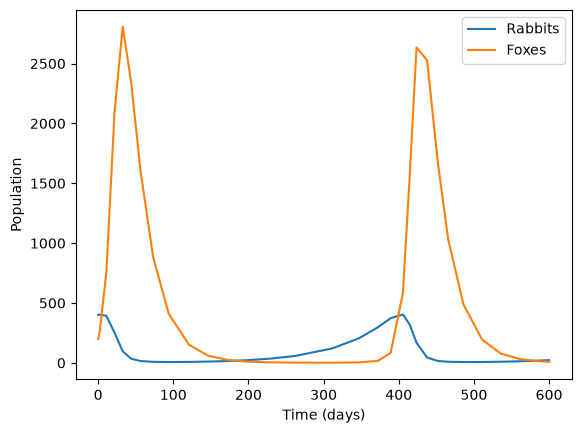

In [9]:
def dydt(t, y):
    R, F = y
    dRdt = k1 * R - k2 * R * F
    dFdt = k3 * R * F - k4 * F
    return [dRdt, dFdt]

sol = solve_ivp(dydt, (0, 600), y0)

print(sol.success)  # Check if the integration was successful
print(sol.nfev)  # Number of function evaluations
print(len(sol.t))  # Number of time points in the solution

plt.plot(sol.t, sol.y[0], label='Rabbits')
plt.plot(sol.t, sol.y[1], label='Foxes')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.legend()
plt.show()

Your plot is probably jagged. Why? Fix it in two ways: with `t_eval`, and with
`dense_output=True`. Does either one change `sol.nfev`?

same number of function evaluations: 242 242


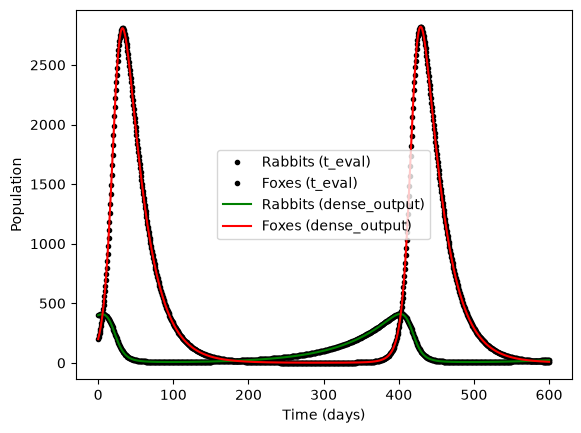

In [10]:
times = np.linspace(0, 600, 1001)
sol_eval = solve_ivp(dydt, (0, 600), y0, t_eval=times)
sol_dense = solve_ivp(dydt, (0, 600), y0, dense_output=True)
print("same number of function evaluations:", sol_eval.nfev, sol_dense.nfev)

plt.plot(sol_eval.t, sol_eval.y[0], "k.", label='Rabbits (t_eval)')
plt.plot(sol_eval.t, sol_eval.y[1], "k.", label='Foxes (t_eval)')
plt.plot(times, sol_dense.sol(times)[0], "g-", label='Rabbits (dense_output)')
plt.plot(times, sol_dense.sol(times)[1], "r-", label='Foxes (dense_output)')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.legend()
plt.show()

*Answer: The plot was jagged because the solver used only 32 time points across 600 days, leaving wide gaps where straight line plotting looks angular. Neither t_eval nor dense_output=True changed sol.nfev which is still 242. Because solve_ivp takes the same exact adaptive integration steps regardless, using polynomial interpolation to evaluate the requested intermediate points.*

## 2. The phase portrait

Solve to 1200 days, three full cycles, and plot foxes against rabbits. The exact
solution is a closed loop, traced over and over. Is yours?

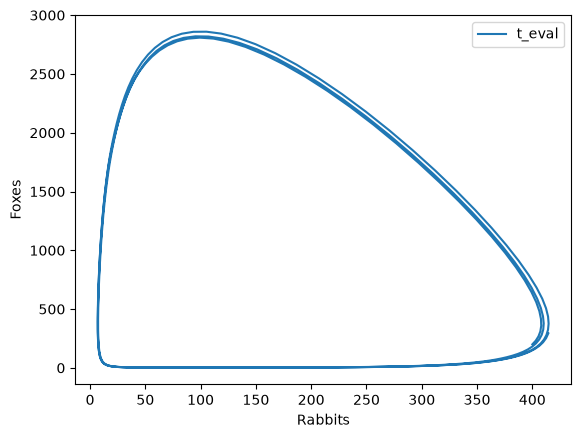

In [12]:
times = np.linspace(0, 1200, 1001)
sol_eval = solve_ivp(dydt, (0, 1200), y0, t_eval=times)

plt.plot(sol_eval.y[0], sol_eval.y[1], label='t_eval')
plt.xlabel('Rabbits')
plt.ylabel('Foxes')
plt.legend()
plt.show()

*Answer: It is not a perfect closed loop. Each cycle/loop dirfts slighly outwards compared to the previous one due to the accumulation of errors over time.*

## 3. The height of each fox peak, using events

Searching `sol.y` for the largest value gives you the largest value **at the times
the solver happened to stop**, which won't be exactly at the peak. `solve_ivp` can
find the exact moment instead, with an *event*: a function `g(t, y)` that it
watches. It reports every time `g` passes through zero.

The foxes peak when $dF/dt$ changes from positive to negative. Since
$dF/dt = F(k_3 R - k_4)$ and $F > 0$, that happens when $k_3 R - k_4$ goes from
positive to negative. So:

```python
def fox_peak(t, y):
    R, F = y
    return k3 * R - k4

fox_peak.direction = -1   # only count it when g is decreasing through zero

sol = solve_ivp(dydt, (0, 1200), y0, events=fox_peak)
sol.t_events[0]          # the times of the peaks
sol.y_events[0]          # the [R, F] values at each one
```

Print the time and height of each fox peak, with the default tolerances. Compare
with the Euler peaks above. How many function evaluations did it take, compared
with Euler's 12,000 or 240,000 steps?

*Answer:*

## 4. Required accuracy: `rtol`

The true peaks are all the same height. So the *drift*, last peak minus first, is a
measure of the error, and we don't need the exact answer to find it.

Loop over `rtol` from `1e-3` to `1e-10`, keeping `atol = 1e-8`. For each value
record the drift and `sol.nfev`. Then make two log-log plots: |drift| against
`rtol`, and |drift| against `nfev`. The second is called a *work–precision
diagram*.

- How tight must `rtol` be for the peaks to agree to within one fox? To within
  0.01 of a fox?
- What is the height of the fox peak, to as many significant figures as you can
  justify? How do you know?
- Euler with 240,000 steps had a drift of 3.7 foxes. How many function evaluations
  does `solve_ivp` need to do better than that?

*Answer:*

## 5. `atol`, and how few foxes is too few?

What is the **smallest** number of foxes during the cycle, and of rabbits? (Use
`dense_output=True` and a fine grid of times, or another event.)

Now someone argues: "A fraction of a fox is meaningless, so I'll set `atol = 1`."
Try it, with `rtol = 1e-6`. Then try `atol = 10`. What happens to the peaks? Explain
why, using the formula for the error tolerance, $\text{atol} + \text{rtol}\,|y|$.

And about the model itself: what does a population of under two foxes mean? Would a
real population survive that trough? (Lecture 10, kinetic Monte Carlo, is one way
to model that properly.)

*Answer:*

## 6. Which method?

At `rtol = 1e-8, atol = 1e-8`, compare `method=` `"RK45"`, `"DOP853"`, `"LSODA"`,
`"BDF"` and `"Radau"`: drift and `nfev` for each. Which is cheapest for this
problem? Is this problem stiff? How can you tell?

*Answer:*

## Stretch problems

**(a)** For this system the quantity
$V = k_3 R - k_4 \ln R + k_2 F - k_1 \ln F$ stays exactly constant. (Differentiate
it and substitute the two ODEs to check.) That's why the orbit is closed. Plot
how much $V$ changes over 1200 days for a few values of `rtol`. Is it a better
measure of the error than the peak drift?

**(b)** Re-run with $k_3 = 0.00004$ day$^{-1}$ rabbits$^{-1}$ for 800 days, as in
Lecture 3. The fixed point moves from (100, 375) to (1000, 375). Do your
conclusions about `rtol` change?

---

### When you're done

Restart & Run All. Check that every cell ran, in order, with no errors. Commit and
push. Then check on GitHub that your fork shows your latest commit, and that the
notebook displays with its plots.